In [1]:
import os
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
import itpo_weights
from graph_utils import LJInteractionParams, prepare_traj
from ift import no_bootstrap_rollout_implicit, specialized_rollout_implicit
from itpo_weights import DatasetType, ModelType
from pressure import compute_stress_curve, compute_total_stress
from simulator_SA_cpu_test import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    get_rollout,
    load_and_split_dataset,
    rollout_cascade,
    simulate_then_rollout,
    specialized_rollout,
    specialized_rollout_cascade,
    visualize_nu_disribution,
)

### Data

Loading data...


test  data: 100%|██████████| 35/35 [00:04<00:00,  7.57it/s]



Preparing data...


test  data: 100%|██████████| 35/35 [00:08<00:00,  4.23it/s]


Train data: 68 sims.
Val data:   34 sims.
Test data:  35 sims.


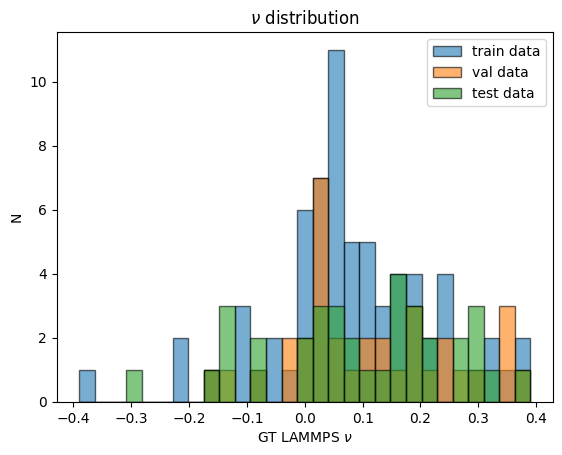

In [4]:
# poisson_buckets = [
#     {"max": 0.1, "count": 300},             # P < 0.1
#     {"min": 0.1, "max": 0.2, "count": 100}, # 0.1 <= P < 0.2
#     {"min": 0.2, "count": 100}              # P >= 0.2
# ]
poisson_buckets = [
    {"max": 0.1, "count": 100},             # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 30}, # 0.1 <= P < 0.2
    {"min": 0.2, "count": 30}              # P >= 0.2
]

dataset_type = DatasetType.NodeOptimized

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    # registry_path="./data/data_registry.csv",
    registry_path="./data/new_node_optimized/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

print("Loading data...")
max_sim_len = 20000000
# stride = 5
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        lj_params = LJInteractionParams(0.01, 1.0, 1.122) if dataset_type is DatasetType.LJNoisy else None
        prepared_sim = prepare_traj(sim, lj_params, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")

visualize_nu_disribution(data)


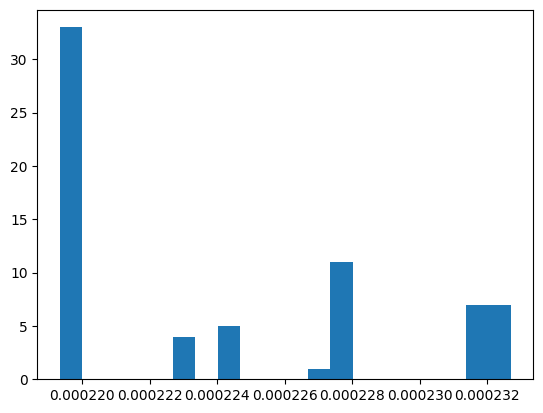

In [8]:
box_deltas = [sim[3].box_tensor[0] - sim[4].box_tensor[0] for sim in data['train']]

plt.hist(box_deltas, bins=20)
plt.show()

### Load pretrained models

In [ ]:
device = "cuda"
simulator_type = ModelType.GNNModel # ModelType.GNNModel | ModelType.SimulatorCascade

match simulator_type:
    case ModelType.GNNModel:
        mp_layers = 2
        mlp = 3
        hidden_size = 128
        history = 3

        edge_features = 7 if dataset_type is DatasetType.LJNoisy else 4
        init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, edge_features)))

        models = {}

        # model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        # model.load_checkpoint(f"./trained_models/{dataset_type}/OST/model_P>0.1_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
        # model = freeze_normalizer(model)
        # models[f"h{history} P>0.1 ost"] = model

        # model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        # model.load_checkpoint(f"./trained_models/{dataset_type}/MST/model_P>0.1_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
        # model = freeze_normalizer(model)
        # models[f"h{history} P>0.1 mst"] = model

        model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        model.load_checkpoint(f"./new_trained_models/{dataset_type}/MST/checkpoint_epoch_120.pt")
        model = freeze_normalizer(model)
        models[f"h{history} P>0.1 mst"] = model

        # model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        # model_path = "./LJ_trained_models/lj_noisy/MST/trained_model/checkpoint_epoch_87.pt"
        # model.load_checkpoint(model_path)
        # model = freeze_normalizer(model)
        # models[f"h{history} mst"] = model

        for i, model_name in enumerate(models.keys()):
            print(f"{i+1}. Model {model_name}.")

    case ModelType.SimulatorCascade:
        hidden_size = 128
        mp_layers = 2
        mlp = 3
        epochs = 100

        device = 'cuda'
        # model_save_path = os.path.join("./trained_models", f"{dataset_type}", "cascade", "refined_P>0.2")
        model_save_path = os.path.join("./full_range_models", f"{dataset_type}", "cascade", "refined")
        n_models = len(os.listdir(model_save_path))

        models = []
        for h in tqdm(range(n_models)):
            if h == 0:
                n_graphs = 1
            else:
                n_graphs = h+1
            
            init_graph = build_velocity_graph_correction([data['val'][0][i].cpu().detach() for i in range(n_graphs)], panic_at_positions=False).to(device)

            current_h_model = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
            current_h_model.load_checkpoint(os.path.join(model_save_path, f"model_refined_h{h}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))
            current_h_model = freeze_normalizer(current_h_model)
            for param in current_h_model.parameters():
                param.requires_grad = False
            models.append(current_h_model)

        print(f"Loaded cascade of {len(models)} pretrained models.")    


### Test ITPO - Bootstrapped GNN Simulator & Simulator cascade

In [ ]:
def ITPO_gnn_simulator_simple(rollout_steps: int, full_range: bool, lj_params: LJInteractionParams | None, device: str = "cuda") -> dict:
    """Identical to the following function expect no bootstraping 
    since that would take 10_000 MD steps per input and is very very long.
    """
    
    weights = itpo_weights.get_params(simulator_type, dataset_type)
    print(weights)
    max_name_len = max([len(n) for n in models])+1 

    cutoff = lj_params.cutoff if lj_params is not None else None
    
    model_results = {}
    for model_name, model in models.items():
        model.eval()
        history = int(model_name[1])
        target_idx = rollout_steps + history + 1

        local_results = {}
        for mode in ('itpo', 'default'):
            results = {
                "mse": [],
                "pred_p": [],
                "pred_p_function": [],
                "gt_p": [],
                "gt_p_function": [],
                "gt_box": [],
                "pred_box": [],
                "gt_stress": [],
                "pred_stress": [],
            }

            with torch.no_grad():
                # for val_sim in tqdm(data['test'][:100], desc=f"Model {model_name:<{max_name_len}}"):
                for val_sim in tqdm(data['train'][:10], desc=f"Model {model_name:<{max_name_len}}"):
                    
                    # Compute dumping period (N MD steps in 1 dump step)        
                    sim_strain = (val_sim[0].box.x - val_sim[-1].box.x) / val_sim[0].box.x
                    assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
                    dump_period = int(assumed_rollout_length / len(val_sim)) + 1

                    # Select correct barostat parameters
                    if dataset_type is DatasetType.NodeOptimized:
                        barostat_config = barostat_parameters.node_optimizated
                    elif dataset_type is DatasetType.StiffOptimized:
                        barostat_config = barostat_parameters.stiff_optimized
                    elif dataset_type is DatasetType.StiffAngles:
                        barostat_config = barostat_parameters.stiff_angles
                    elif dataset_type is DatasetType.Noisy:
                        barostat_config = barostat_parameters.noisy
                    elif dataset_type is DatasetType.LJNoisy:
                        barostat_config = barostat_parameters.lj_noisy
                    else:    
                        raise ValueError()

                    input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]
                    barostat_config_current = deepcopy(barostat_config)
                    barostat_config_current["default_skip"] = dump_period    
                    
                    if mode == 'default': # no bootstrap rollout without ITPO    
                        rollout = get_rollout(
                            input_graphs=input_graphs,
                            gnn_simulator=model,
                            gnn_history=history,
                            num_steps=rollout_steps,
                            barostat_config=barostat_config_current,
                            lj_params=lj_params,
                            device=device
                        )
                    
                    elif mode == 'itpo': # no bootstrap rollout with ITPO
                        rollout = no_bootstrap_rollout_implicit(
                            input_graphs=input_graphs,
                            gnn_simulator=model,
                            gnn_history=history,
                            barostat_config=barostat_config_current,
                            lj_params=lj_params,
                            itpo_weights=weights,
                            rollout_steps=rollout_steps,
                            device=device
                        )
                
                    # Compute position MSE
                    pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
                    results["mse"].append(pos_mse)
                
                    # Compute predicted and GT Poisson's ratio
                    pred_p = calc_p_ratio_box_tensor(rollout).item()
                    results["pred_p"].append(pred_p)
                    gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
                    results["gt_p"].append(gt_p)

                    # Poisson's ratio as a function of rollout step
                    gt_p_change = [calc_p_ratio_box_tensor(val_sim[:i]).item() for i in range(1, target_idx)]
                    results["gt_p_function"].append(gt_p_change)
                    pred_p_change = [calc_p_ratio_box_tensor(rollout[:i]).item() for i in range(1, target_idx)]
                    results["pred_p_function"].append(pred_p_change)

                    # Periodic box behaviour
                    pred_box = [g.box_tensor.cpu() for g in rollout]
                    results["pred_box"].append(pred_box)
                    gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
                    results["gt_box"].append(gt_box)

                    # Compute pressure
                    gt_stress = compute_stress_curve(val_sim[:target_idx+1], lj_cutoff=cutoff, sample_stride=1, device=device)
                    results['gt_stress'].append(gt_stress)
                    pred_stress = compute_stress_curve(rollout, lj_cutoff=cutoff, sample_stride=1, device=device)
                    results["pred_stress"].append(pred_stress)

            local_results[mode] = results
        model_results[model_name] = local_results
    
    return model_results


def ITPO_gnn_simulator(rollout_steps: int, full_range: bool, lj_params: LJInteractionParams | None, device: str = "cuda") -> dict:

    weights = itpo_weights.get_params(simulator_type, dataset_type)
    print(weights)
    max_name_len = max([len(n) for n in models])+1 

    cutoff = lj_params.cutoff if lj_params is not None else None
    
    model_results = {}
    for model_name, model in models.items():
        model.eval()
        history = int(model_name[1])
        target_idx = rollout_steps + history + 1

        local_results = {}
        for mode in ('itpo', 'default'):
            results = {
                "mse": [],
                "pred_p": [],
                "pred_p_function": [],
                "gt_p": [],
                "gt_p_function": [],
                "gt_box": [],
                "pred_box": [],
                "gt_stress": [],
                "pred_stress": [],
            }

            with torch.no_grad():
                for val_sim in tqdm(data['test'][:50], desc=f"Model {model_name:<{max_name_len}}"):
                    
                    # Compute dumping period (N MD steps in 1 dump step)        
                    sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
                    assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
                    dump_period = int(assumed_rollout_length / len(val_sim)) + 1

                    # Select correct barostat parameters
                    if dataset_type is DatasetType.NodeOptimized:
                        barostat_config = barostat_parameters.node_optimizated
                    elif dataset_type is DatasetType.StiffOptimized:
                        barostat_config = barostat_parameters.stiff_optimized
                    elif dataset_type is DatasetType.Noisy:
                        barostat_config = barostat_parameters.noisy
                    elif dataset_type is DatasetType.LJNoisy:
                        barostat_config = barostat_parameters.lj_noisy
                    else:    
                        raise ValueError()

                    input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]
                    barostat_config_current = deepcopy(barostat_config)
                    barostat_config_current["default_skip"] = dump_period    
                    
                    if mode == 'default': # MD bootstrapped rollout with no ITPO    
                        rollout = simulate_then_rollout(
                            starting_graph=input_graphs[0],
                            gnn_simulator=model,
                            rollout_steps=rollout_steps,
                            gnn_history=history,
                            barostat_config=barostat_config_current,
                            lj_params=lj_params,
                            md_steps=(dump_period*history)+1,
                            device="cuda"
                        )
                    
                    elif mode == 'itpo': # MD bootstrapped rollout with ITPO
                        rollout = specialized_rollout_implicit(
                            starting_graph=input_graphs[0],
                            gnn_simulator=model,
                            gnn_history=history,
                            barostat_config=barostat_config_current,
                            lj_params=lj_params,
                            itpo_weights=weights,
                            md_steps=(dump_period*history)+1,
                            rollout_steps=rollout_steps,
                            device="cuda"
                        )
                
                    # Compute position MSE
                    pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
                    results["mse"].append(pos_mse)
                
                    # Compute predicted and GT Poisson's ratio
                    pred_p = calc_p_ratio_box_tensor(rollout).item()
                    results["pred_p"].append(pred_p)
                    gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
                    results["gt_p"].append(gt_p)

                    # Poisson's ratio as a function of rollout step
                    gt_p_change = [calc_p_ratio_box_tensor(val_sim[:i]).item() for i in range(1, target_idx)]
                    results["gt_p_function"].append(gt_p_change)
                    pred_p_change = [calc_p_ratio_box_tensor(rollout[:i]).item() for i in range(1, target_idx)]
                    results["pred_p_function"].append(pred_p_change)

                    # Periodic box behaviour
                    pred_box = [g.box_tensor.cpu() for g in rollout]
                    results["pred_box"].append(pred_box)
                    gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
                    results["gt_box"].append(gt_box)

                    # Compute pressure
                    gt_stress = compute_stress_curve(val_sim[:target_idx+1], lj_cutoff=cutoff, sample_stride=1, device=device)
                    results['gt_stress'].append(gt_stress)
                    pred_stress = compute_stress_curve(rollout, lj_cutoff=cutoff, sample_stride=1, device=device)
                    results["pred_stress"].append(pred_stress)

            local_results[mode] = results
        model_results[model_name] = local_results
    
    return model_results


def ITPO_simulator_cascade(rollout_steps: int, full_range: bool) -> dict:

    factors = [(sim[4].box_tensor[0] - sim[3].box_tensor[0]).item() for sim in data["test"]]
    mean_delta_x = sum(factors)/len(factors)

    weights = itpo_weights.get_params(simulator_type, dataset_type, full_range=full_range)

    target_idx = rollout_steps
    model_results = {}
    local_results = {}
    for mode in ("itpo", 'default'):
        results = {
        "mse": [],
        "pred_p": [],
        "pred_p_function" : [],
        "gt_p": [],
        "gt_p_function" : [],
        "gt_box": [],
        "pred_box": [],
        "gt_pressure": [],
        "pred_pressure": [],
    }

        with torch.no_grad():
            for val_sim in tqdm(data['test']):

                if dataset_type is DatasetType.NodeOptimized:
                    barostat_config = barostat_parameters.node_optimizated
                elif dataset_type is DatasetType.StiffOptimized:
                    barostat_config = barostat_parameters.stiff_optimized
                else: 
                    raise ValueError()

                if mode == 'default':
                    rollout = rollout_cascade(
                        models=models,
                        initial_state=val_sim[0].cpu().detach(),
                        num_steps=rollout_steps,
                        barostat_config=barostat_config,
                        box_delta_x=mean_delta_x,
                        device='cuda'
                    )
                elif mode == "itpo":
                    rollout = specialized_rollout_cascade(
                        starting_graph=val_sim[0].cpu().detach(),
                        gnn_models=models,
                        barostat_config=barostat_config,
                        box_delta_x=mean_delta_x,
                        itpo_weights=weights,
                        rollout_steps=rollout_steps,
                        device='cuda'
                    )
            
            # Compare Predicted Position vs Ground Truth Position
                pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
                results["mse"].append(pos_mse)
            
                pred_p = calc_p_ratio_box_tensor(rollout).item()
                results["pred_p"].append(pred_p)
                gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
                results["gt_p"].append(gt_p)

                pred_box = [g.box_tensor.cpu() for g in rollout]
                results["pred_box"].append(pred_box)
                gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
                results["gt_box"].append(gt_box)

            # P as a function of rollout step
                gt_p_change = [calc_p_ratio_box_tensor(val_sim[:i]).item() for i in range(1, target_idx)]
                results["gt_p_function"].append(gt_p_change)
                pred_p_change = [calc_p_ratio_box_tensor(rollout[:i]).item() for i in range(1, target_idx)]
                results["pred_p_function"].append(pred_p_change)

                r0 = rollout[0].edge_attr[:, -2]
                gt_pressure = torch.stack([compute_total_stress(g, r0=r0, temperature=1e-7).cpu() for g in val_sim[: len(rollout)]], dim=0)
                results['gt_pressure'].append(gt_pressure)
                pred_pressure = torch.stack([compute_total_stress(g, r0=r0, temperature=1e-7).cpu() for g in rollout], dim=0)
                results["pred_pressure"].append(pred_pressure)

        local_results[mode] = results

    model_results['cascade'] = local_results
    return model_results


rollout_steps = 50
if simulator_type is ModelType.GNNModel:
    model_results = ITPO_gnn_simulator(rollout_steps, full_range=False, lj_params=lj_params, device=device)
    # model_results = ITPO_gnn_simulator_simple(rollout_steps, full_range=False, lj_params=lj_params, device=device)
elif simulator_type is ModelType.SimulatorCascade:
    model_results = ITPO_simulator_cascade(rollout_steps, full_range=False)


### Plot results

In [ ]:
params = {
    'font.size': 6,                 # Base font size
    'axes.labelsize': 6,            # Axis labels
    'axes.titlesize': 6,            # Subplot titles
    'xtick.labelsize': 6,           # Tick x numbers
    'ytick.labelsize': 6,           # Tick y numbers
    'legend.fontsize': 4,           # Make legend smaller to fit
    'lines.markersize': 3,          # Reduce scatter dot size
    'figure.figsize': (3.33, 3.33), # Target figure size in inches
    'figure.dpi': 200,              # DPI
    'font.family': 'serif',         # Font
}
plt.rcParams.update(params)

fig, ax = plt.subplots(1, 1, layout="constrained")

gt_p = model_results[sorted(model_results.keys())[0]]['itpo']['gt_p']
line = (min(gt_p) - 0.05, max(gt_p) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, local_results in model_results.items():
    
    for mode, results in local_results.items():
        r2 = r2_score(results['gt_p'], results['pred_p'])
        res = spearmanr(results["gt_p"], results["pred_p"])
        sp = res.statistic
        label_text = f"{model_name}, mode: {mode} -- $R^2={r2:.3f}$, SP={sp:.3f}"
        ax.scatter(results["gt_p"], results["pred_p"], label=label_text)

ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")

plt.show()


In [ ]:
params = {
    'font.size': 6,                 # Base font size
    'axes.labelsize': 6,            # Axis labels
    'axes.titlesize': 6,            # Subplot titles
    'xtick.labelsize': 6,           # Tick x numbers
    'ytick.labelsize': 6,           # Tick y numbers
    'legend.fontsize': 4,           # Make legend smaller to fit
    'lines.markersize': 2,          # Reduce scatter dot size
    'figure.figsize': (3.33, 3.33), # Target figure size in inches
    'figure.dpi': 300,              # DPI
    'font.family': 'serif',         # Font
}
plt.rcParams.update(params)

fig, ax = plt.subplots(2, 2, layout="constrained")

line = (min(results["gt_p"]) - 0.05, max(results["gt_p"]) + 0.05)
ax[0][0].plot(line, line, color="black", linewidth=1, linestyle='--')
ax[0][1].plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, local_results in model_results.items():
    if 'P>0.2' in model_name:
        active_ax = ax[0][0]
        active_ax.set_title(r'$\nu > 0.2$')
    else:
        active_ax = ax[0][1]
        active_ax.set_title(r'$\nu > 0.1$')
    for mode, results in local_results.items():
        r2 = r2_score(results['gt_p'], results['pred_p'])
        res = spearmanr(results["gt_p"], results["pred_p"])
        sp = res.statistic
        label_text = f"{model_name[:2]} | {mode} | $R^2={r2:.3f}$"
        active_ax.scatter(results["gt_p"], results["pred_p"], label=label_text)
        active_ax.legend(frameon=False, loc='best')

for model_name, local_results in model_results.items():

    if 'P>0.2' in model_name:
        active_ax = ax[1][0]
    else:
        active_ax = ax[1][1]
    
    for mode, results in local_results.items():
        r2 = r2_score(results['gt_p'], results['pred_p'])
        res = spearmanr(results["gt_p"], results["pred_p"])
        sp = res.statistic
        label_text = f"mode: {mode}"
        active_ax.scatter(results["gt_p"], [m[-1] for m in results["mse"]], label=label_text)
        active_ax.legend(frameon=False, loc='best')


ax[1][0].set_xlabel(r"$\nu_{gt}$")
ax[1][1].set_xlabel(r"$\nu_{gt}$")
ax[0][0].set_ylabel(r"$\nu_{pred}$")
ax[1][0].set_ylabel("Position MSE")

plt.show()


In [ ]:
rand_sim = random.randint(0, len(data['test'][:10]))

label_map = {
    'itpo' : 'itpo',
    'default' : 'default',
}

for model_name, local_results in model_results.items():
    for mode, results in local_results.items():
        plt.plot(results["mse"][rand_sim], label=f"{model_name} - {label_map[mode]}")

plt.legend()
plt.title(f"Sim {rand_sim}")
plt.xlabel('Rollout step')
plt.ylabel('Position MSE')
plt.yscale('log')
plt.show()

In [ ]:
rand = random.randint(0, len(data["test"][:10]))

for model_name, local_results in model_results.items():
    
    # if model_name != "h3 mst":
        # continue
    tto_results = local_results["itpo"]
    default_results = local_results['default']

    box_y_true = [tto_results["gt_box"][rand][i][1].item() for i in range(1, rollout_steps)]
    box_x_true = [tto_results["gt_box"][rand][i][0].item() for i in range(1, rollout_steps)]

    box_y_roll_tto = [tto_results["pred_box"][rand][i][1].item() for i in range(1, rollout_steps)]
    box_x_roll_tto = [tto_results["pred_box"][rand][i][0].item() for i in range(1, rollout_steps)]

    box_y_roll_default = [default_results["pred_box"][rand][i][1].item() for i in range(1, rollout_steps)]
    box_x_roll_default = [default_results["pred_box"][rand][i][0].item() for i in range(1, rollout_steps)]


    fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(6, 3))

    ax[0].plot(box_y_true, label="GT")
    ax[0].plot(box_y_roll_tto, label=f"{model_name} ITPO")
    ax[0].plot(box_y_roll_default, label=f"{model_name} Default")
    ax[0].set_ylabel("$L_y$")
    ax[0].legend()

    ax[1].plot(box_x_true, label="GT")
    ax[1].plot(box_x_roll_tto, label=f"{model_name} ITPO")
    ax[1].plot(box_x_roll_default, label=f"{model_name} Default")
    ax[1].set_ylabel("$L_x$")
    ax[1].legend()

plt.show()

In [ ]:
rand = random.randint(0, len(data["test"][:10]))

for model_name, result in model_results.items():

    tto_results = result["itpo"]

    pred_stress = tto_results['pred_stress'][rand]
    pred_pressure = torch.abs(pred_stress[:, 0] + pred_stress[:, 1]) / 2

    plt.plot(pred_stress[:, 0].cpu().detach(), label=f"{model_name}")


# Plot GT pressure
gt_stress = model_results[sorted(model_results.keys())[0]]['itpo']['gt_stress'][rand]
gt_pressure = torch.abs(gt_stress[:, 0] + gt_stress[:, 1]) / 2
plt.plot(gt_stress[:, 0].cpu().detach(), label="GT")

# Plot linear fit
fit_to_steps = 5
x_fit = np.array(range(fit_to_steps))
y_fit = np.array(gt_stress[:fit_to_steps, 0].cpu().detach())
a, b = np.polyfit(x_fit, y_fit, deg=1)
linear = [a*i + b for i in range(len(gt_pressure))]

plt.plot(linear, linestyle="--", color="black")
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Rollout step")
plt.legend()
plt.show()


In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(3, 3), layout="tight")

deltas = [(box_x_true[i+1] - box_x_true[i])/box_x_true[0] for i in range(rollout_steps-2)]
deltas_tto = [(box_x_roll_tto[i+1] - box_x_roll_tto[i])/box_x_roll_tto[0] for i in range(rollout_steps-2)]

# random_sim = random.sample(data['test'], k=1)[0]

# factors = [(random_sim[i+1].box_tensor[0] / random_sim[i].box_tensor[0]).item() for i in range(90)]
# deltas = [(random_sim[i+1].box_tensor[0] - random_sim[i].box_tensor[0]).item() for i in range(90)]
# factors_tto = [box_x_roll_tto[i+1] / box_x_roll_tto[i] for i in range(90)]

ax1.plot(deltas, color="blue")
ax1.plot(deltas_tto, color="blue", linestyle="--")
# ax1.plot(factors, color="blue")
# ax1.plot(factors_tto, color="blue", linestyle="--")
ax1.set_ylabel("Per step compression factor", color="blue")
ax1.set_xlabel("Rollout step")

ax2 = ax1.twinx()
ax2.plot(box_x_true[:90], color="red")
ax2.plot(box_x_roll_tto[:90], color="red", linestyle="--")

# x_fit = np.array(range(len(box_x_true[:90])))
# y_fit = box_x_true[:90]
# a, b = np.polyfit(x_fit, y_fit, deg=1)
# fit_line = [a*v + b for v in x_fit]

# r2 = r2_score(box_x_true[:90], fit_line)
# ax2.plot(fit_line, color="black", label=f"$R^2 = {r2:.10f}$")
ax2.legend()

ax2.set_ylabel("$L_x$", color="red")

plt.show()

### Plotting - r2 and mse as a function of step

In [ ]:
# i = random.randint(0, len(data["test"]))
i = random.randint(0, 50)
for model_name, result in model_results.items():
    plt.plot(result["itpo"]['gt_p_function'][i], label='gt')
    plt.plot(result["itpo"]['pred_p_function'][i], label="itpo")
    # plt.plot(result['default']['pred_p_function'][i], label='default')
    plt.ylabel(r'$\nu$')
    plt.xlabel('step')
    plt.legend()

plt.show()

In [ ]:
r2s = {
    "itpo": [],
    'default': [],
}

for model_name, local_results in model_results.items():
        for mode, results in local_results.items():
            for step in range(1, rollout_steps-1):
                pred_p_to_step = [p[step] for p in results['pred_p_function']]
                gt_p_to_step = [p[step] for p in results['gt_p_function']]
                
                r2 = r2_score(gt_p_to_step, pred_p_to_step)
                r2s[mode].append(r2)
step_size = 10
steps = np.array(range(10, rollout_steps-1, step_size))
width = step_size // 2 - 1

# Calculate offsets
plt.bar(steps - width/2, [r2s["itpo"][i] for i in steps], width=width, label='ITPO')
# plt.bar(steps + width/2, [r2s['default'][i] for i in steps], width=width, label='default')

plt.legend()
plt.xlabel('Rollout step')
plt.ylabel('$R^2$')
plt.xticks(steps)
plt.show()